# 01 · Do fingerprint à posição — Antwerp

**MACHINE LEARNING MEETS NETWORKS · ERRC 2026**  
Lorenzo Moreira Donatti · Deivis Felipe Guerreiro Fagundes

Nesta aula, vamos localizar um dispositivo LoRaWAN com sinais de vários gateways e avaliar quando essa estimativa é útil.

### Como acompanhar esta aula

Comece pela leitura dos dados e acompanhe as perguntas propostas em cada seção.
O código está pronto para executar; durante a aula, vamos discutir as escolhas e os resultados.
Use **Shift + Enter** para executar uma célula. No Colab, salve uma cópia no Drive.

**Distribuição dos 40 minutos:** ambiente (2) → contrato (3) → exploração (13) → divisão (4) → métodos (5) → avaliação (8) → contraponto (5)

Este notebook é uma aula independente. CSVs pequenos são lidos do GitHub Raw; ambiente CPU padrão.
É necessário acesso à Internet. Não é preciso clonar o repositório nem montar o Drive.
O teste de ambiente foi incorporado ao passo 0: abra e execute as duas primeiras células antes do evento.

## 0 · Preparação · 2 min

Execute as duas células. O Colab baixa os CSVs pequenos do GitHub Raw automaticamente.
Não é preciso clonar o repositório, montar o Drive ou enviar arquivos manualmente.
A versão dos dados está fixada por commit e conferida por SHA-256. Internet é necessária.
**Conferência:** 12.000 pacotes, 39 colunas de RSSI e metadados. Apenas RSSI entra nos modelos.
Os dados completos ficam com os tutores; este recorte reduz memória e tempo de execução.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True, 'grid.alpha': 0.25})

In [2]:
# Dados públicos; versão fixada para reproduzir a aula.
import hashlib
import io
from urllib.request import urlopen

BASE_DADOS = 'https://raw.githubusercontent.com/LorenzoDonatti/ML_meets_networks_ERRC2026/e7b18b4133d3544ad4d6ed15e3599167031c54f7/data'

def carregar_csv(nome, sha256):
    with urlopen(f"{BASE_DADOS}/{nome}", timeout=30) as resposta:
        conteudo = resposta.read()
    assert hashlib.sha256(conteudo).hexdigest() == sha256, "Arquivo diferente da versão da aula."
    return pd.read_csv(io.BytesIO(conteudo))

df = carregar_csv('antwerp_localization.csv', '3e608fc640763ca9aa26ac81da3e8c020de6eb2c66ccc8c4d0a1a2a41eb98831')
print("Dados carregados:", df.shape)
# Coordenadas oficiais, vinculadas às features por ID.
gateway_info = carregar_csv("antwerp_gateways.csv", '51a8e5cbb16f3412a53a23ff1d527e02ec673fb744fe8fd941694eff60c24793')


Dados carregados: (12000, 46)


## 1 · O que estamos tentando localizar? · 3 min

Um dispositivo envia um uplink. Vários gateways podem recebê-lo. Queremos localizar
o **transmissor**, depois de reunir as recepções desse pacote — não localizar o gateway.

```text
                    ┌─ GW A: RSSI A ─┐
mesmo uplink LoRa ───┼─ GW B: RSSI B ─┼─→ fingerprint → posição do transmissor
                    └─ GW C: ausente ┘
```

| Informação | Papel |
|---|---|
| RSSI por gateway | Entrada, já disponível após a recepção |
| GPS do transmissor | Resposta de referência, nunca entrada |
| Horário e dispositivo | Metadados para entender a coleta e avaliar |
| Coordenadas fixas dos gateways | Infraestrutura conhecida, usada pelo centroide |

Cada linha representa um pacote; não criamos uma linha de treinamento por gateway.
Também não fazemos média dos RSSIs entre gateways: a identidade de cada receptor importa.
RSSI/SNR do pacote seriam válidos neste instante; usamos só RSSI para simplificar a representação.
Dois lugares poderiam ter fingerprints parecidos?

<details><summary>Comentário para discussão</summary>

Sim. Obstáculos, antenas, orientação e ruído tornam a relação ambígua. Um RSSI não determina uma distância nem uma posição única. Na operação, ainda seria preciso definir quanto esperar pelas recepções de cada uplink.

</details>

## 2 · Conhecer a coleta antes de treinar · 13 min

Fonte: Aernouts et al., Universidade de Antwerp/imec e Sensolus, versão 1.3 do dataset,
JSON de 2019. São 130.430 pacotes no original e 44 IDs de gateway observados no JSON.
O arquivo de coordenadas cobre 39 desses IDs. Para comparar os métodos com os mesmos
receptores, usamos esses 39; 163 pacotes sem recepção em nenhum deles ficam fora.
Isso limita a população avaliada, não significa que esses pacotes sejam inválidos.

Os tutores reservaram dias anteriores para treino, intermediários para validação e posteriores
para teste. Depois sortearam, sem reposição, até 8.000/2.000/2.000 pacotes de cada parte,
com semente 42. **A seleção não usa erros dos modelos nem balanceia posições.**
Não assumimos que uma campanha urbana esteja automaticamente bem distribuída.

### 2.1 · O que é um fingerprint incompleto?

Olhe as primeiras linhas: ausência no JSON vira `NaN`. Não é uma medição de 0 dBm.
Reservamos validação e teste antes da exploração; todos os gráficos desta seção usam treino.

,timestamp,rssi_004A026B,rssi_080605EE,rssi_08060622,rssi_08060716,lat,lon
0,2018-11-17 12:23:09.538215869+00:00,NaN,NaN,NaN,NaN,51.225254,4.402447
1,2018-11-17 21:46:09.753000+00:00,NaN,NaN,NaN,NaN,51.194382,4.418981
2,2018-11-17 22:46:08.715606647+00:00,NaN,NaN,NaN,NaN,51.225254,4.402447
3,2018-11-18 03:48:30.314114994+00:00,NaN,NaN,NaN,NaN,51.194263,4.418986
4,2018-11-18 10:51:14.167000+00:00,NaN,NaN,NaN,NaN,51.194263,4.418935


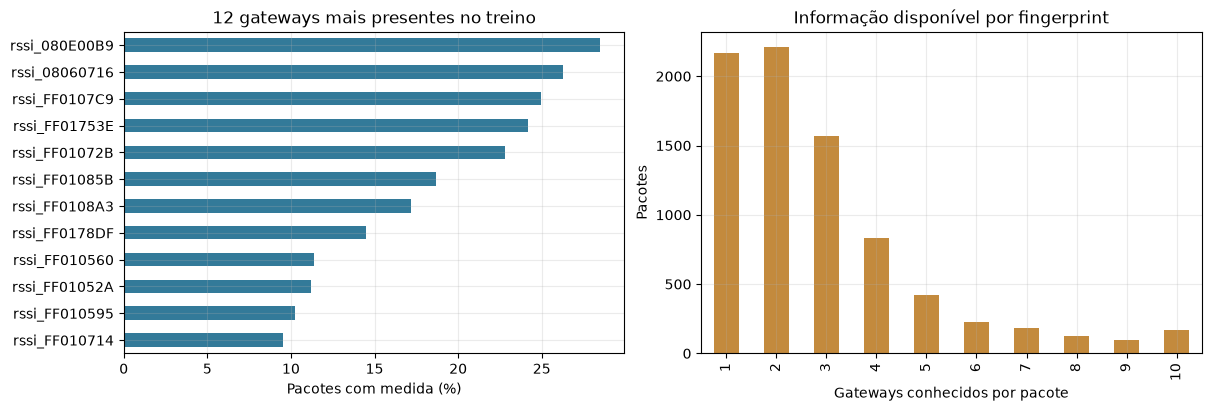

In [3]:
features = gateway_info.feature.tolist()
df['timestamp'] = pd.to_datetime(df.timestamp, utc=True, format='mixed')
treino = df.loc[df.split.eq('treino')].copy()
validacao = df.loc[df.split.eq('validacao')].copy()
teste = df.loc[df.split.eq('teste')].copy()
exploracao = treino
display(exploracao[['timestamp', *features[:4], 'lat', 'lon']].head())
presenca = exploracao[features].notna().mean().sort_values(ascending=False)
destaques = presenca.head(3).index.tolist()  # Escolhidos só pela presença no treino.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
(100 * presenca.head(12)).sort_values().plot.barh(ax=axes[0], color='#337a99')
axes[0].set(xlabel='Pacotes com medida (%)', title='12 gateways mais presentes no treino')
exploracao[features].notna().sum(axis=1).value_counts().sort_index().plot.bar(ax=axes[1], color='#c38a3d')
axes[1].set(xlabel='Gateways conhecidos por pacote', ylabel='Pacotes', title='Informação disponível por fingerprint')
plt.show()

**Pergunta:** 30% de presença significa 70% de perda de pacotes?
    

<details><summary>Comentário para discussão</summary>

Não. Só temos os pacotes registrados nesta campanha; não conhecemos todas as transmissões perdidas. Presença no dataset não é PDR.

</details>

### 2.2 · Onde e por quem os dados foram coletados?

Muitos registros próximos podem dominar uma métrica. O mapa de densidade é tão importante
quanto a quantidade de linhas. Nossa conversão local para metros usa uma origem fixa em
Antwerp (51,22° N; 4,40° E); é uma aproximação para esta área, não uma projeção global.

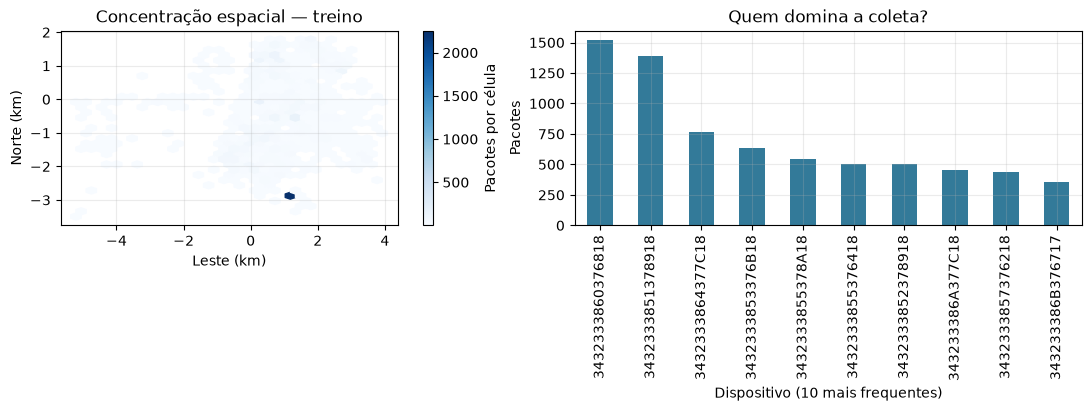

In [4]:
origem = np.array([51.22, 4.40])  # latitude, longitude; referência fixa da cidade
escala = np.array([111320., 111320. * np.cos(np.radians(origem[0]))])
def para_metros(coordenadas):
    return (np.asarray(coordenadas) - origem) * escala
def para_graus(coordenadas):
    return np.asarray(coordenadas) / escala + origem

posicoes = para_metros(exploracao[['lat', 'lon']])
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
mapa = axes[0].hexbin(posicoes[:, 1]/1000, posicoes[:, 0]/1000, gridsize=30, mincnt=1, cmap='Blues')
fig.colorbar(mapa, ax=axes[0], label='Pacotes por célula')
axes[0].set(xlabel='Leste (km)', ylabel='Norte (km)', title='Concentração espacial — treino', aspect='equal')
exploracao.device_id.value_counts().head(10).plot.bar(ax=axes[1], color='#337a99')
axes[1].set(xlabel='Dispositivo (10 mais frequentes)', ylabel='Pacotes', title='Quem domina a coleta?')
plt.show()

### 2.3 · A mesma posição vista por receptores diferentes

Mostramos os três gateways mais presentes no treino; os modelos usarão todos os 39.
Cinza significa ausência. As cores têm a mesma escala em todos os painéis.

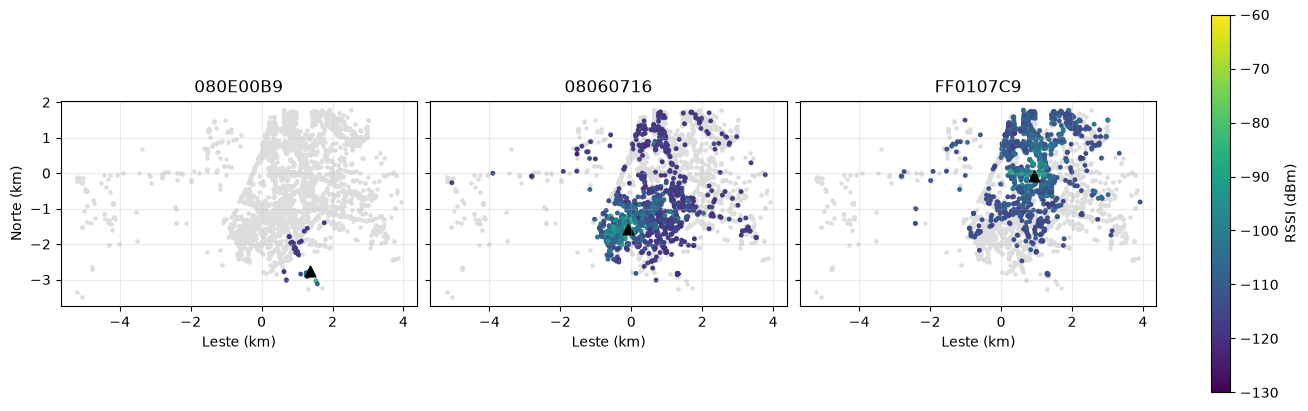

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True, constrained_layout=True)
for ax, coluna in zip(axes, destaques):
    ax.scatter(posicoes[:, 1]/1000, posicoes[:, 0]/1000, s=5, c='#dddddd')
    pontos = ax.scatter(posicoes[:, 1]/1000, posicoes[:, 0]/1000,
                        c=exploracao[coluna], s=6, vmin=-130, vmax=-60, cmap='viridis')
    gw = gateway_info.loc[gateway_info.feature.eq(coluna), ['lat', 'lon']]
    local = para_metros(gw)[0]/1000
    ax.scatter(local[1], local[0], marker='^', c='black', s=60)
    ax.set(title=coluna.removeprefix('rssi_'), xlabel='Leste (km)', aspect='equal')
axes[0].set_ylabel('Norte (km)')
fig.colorbar(pontos, ax=axes, label='RSSI (dBm)')
plt.show()

### 2.4 · Sinais e calendário

Compare as distribuições. Potências parecidas garantem posições próximas?
Observe também a quantidade de dados por dia. Ter milhares de linhas não garante
diversidade de dispositivos, posições ou condições de propagação.

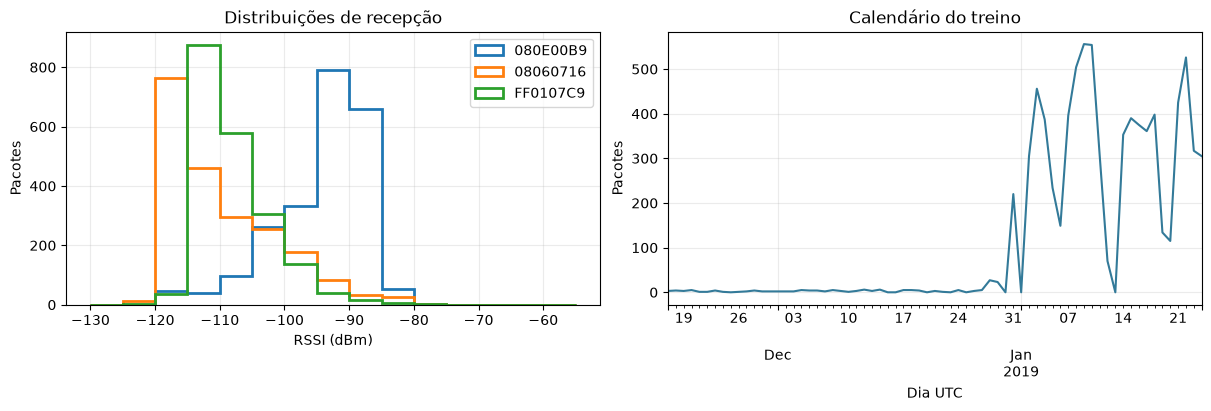

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for coluna in destaques:
    axes[0].hist(exploracao[coluna].dropna(), bins=np.arange(-130, -54, 5),
                 histtype='step', linewidth=2, label=coluna.removeprefix('rssi_'))
axes[0].set(xlabel='RSSI (dBm)', ylabel='Pacotes', title='Distribuições de recepção')
axes[0].legend()
exploracao.set_index('timestamp').resample('D').size().plot(ax=axes[1], color='#337a99')
axes[1].set(xlabel='Dia UTC', ylabel='Pacotes', title='Calendário do treino')
plt.show()

## 3 · O contrato da avaliação · 4 min

**Pergunta:** com dados de dias anteriores, conseguimos localizar pacotes posteriores
desta mesma rede urbana? Não prometemos funcionar em outra cidade ou em áreas inéditas.

```text
tempo → [ treino: 8.000 ] [ validação: 2.000 ] [ teste: 2.000 ]
         aprende          confere escolhas     avaliação final
```

Nenhum dia UTC aparece em duas partes. Lugares e dispositivos podem se repetir:
isso é compatível com monitorar a mesma rede, mas não comprova generalização espacial.
Tampouco garante independência completa entre dias vizinhos.

Usaremos parâmetros fixados antes dos resultados, sem busca em aula. Se quiséssemos
escolher k, faríamos isso na validação, nunca no teste. Não reajustaremos os modelos
entre essas duas avaliações. GPS, horário, ID e nome da partição ficam fora de X.

In [7]:
display(df.groupby('split').agg(N=('packet_id', 'size'),
                               inicio=('timestamp', 'min'), fim=('timestamp', 'max')))
assert treino.timestamp.max() < validacao.timestamp.min()
assert validacao.timestamp.max() < teste.timestamp.min()
X_treino = treino[features]
y_treino = para_metros(treino[['lat', 'lon']])

,N,inicio,fim
split,,,
teste,2000,2019-02-02 05:17:23.120000+00:00,2019-02-05 19:59:38.598244464+00:00
treino,8000,2018-11-17 12:23:09.538215869+00:00,2019-01-24 19:01:09.421510024+00:00
validacao,2000,2019-01-25 06:25:39.485000+00:00,2019-02-01 19:59:05.857000+00:00


## 4 · Três estratégias, poucas linhas · 5 min

| Método | Ideia | O que precisa |
|---|---|---|
| Centroide ponderado | Combinar posições dos gateways, favorecendo RSSI forte | Coordenadas dos gateways |
| k-NN | Buscar cinco fingerprints semelhantes e combinar suas posições | Fingerprints com GPS no treino |
| Random Forest | Aprender regras que relacionam os sinais à posição | Fingerprints com GPS no treino |

A posição mediana do treino entra somente como **controle sem sinais**.
O centroide não transforma RSSI em distância e não é trilateração. Com um gateway,
retorna a posição dele; com vários, permanece na região delimitada pelos receptores.

Para k-NN/RF, ausência recebe −140: um código fixo abaixo das potências do arquivo,
**não uma medição física nem um limiar universal de sensibilidade LoRa**.
Todas as entradas são RSSI na mesma unidade. Não adicionamos SNR/SF ou indicadores
padronizados à distância do k-NN; isso exigiria justificar novos pesos.
A ausência ainda influencia a similaridade: essa representação é uma escolha, não uma verdade física.

O k-NN usa distância entre sinais para buscar vizinhos; as métricas finais usam distância
entre posições. Não confundir as duas distâncias.

In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

def pipeline(estimador):
    return make_pipeline(SimpleImputer(strategy='constant', fill_value=-140,
                                       keep_empty_features=True), estimador)
modelos = {
    'k-NN': pipeline(KNeighborsRegressor(n_neighbors=5, weights='distance')),
    'Random Forest': pipeline(RandomForestRegressor(n_estimators=100, max_depth=20,
                                                   min_samples_leaf=3, random_state=42, n_jobs=1)),
}
for modelo in modelos.values():
    modelo.fit(X_treino, y_treino)

gateways_m = para_metros(gateway_info[['lat', 'lon']])
def estimativas(parte):
    sinais = parte[features].to_numpy()
    pesos = 10 ** ((sinais - np.nanmax(sinais, axis=1, keepdims=True)) / 10)
    pesos = np.nan_to_num(pesos, nan=0.)
    pesos /= pesos.sum(axis=1, keepdims=True)
    saidas = {'Referência sem sinais': np.tile(np.median(y_treino, axis=0), (len(parte), 1)),
              'Centroide ponderado': pesos @ gateways_m}
    saidas.update({nome: modelo.predict(parte[features]) for nome, modelo in modelos.items()})
    return {nome: para_graus(posicao) for nome, posicao in saidas.items()}

<details><summary>Comentário para discussão</summary>

O k-NN busca exemplos pelo padrão de RSSI, não pela distância GPS real do pacote que queremos localizar. Usar essa distância GPS para escolher vizinhos revelaria o target. O centroide usa coordenadas da infraestrutura, que já são conhecidas.

</details>

## 5 · Avaliar e interpretar · 8 min

A função haversine vem pronta: mede distância geográfica em metros.
**Mediana:** metade dos erros fica até esse valor. **P90:** 90% ficam até esse valor;
não é erro máximo nem intervalo de confiança.

Primeiro confira a validação. Os quatro métodos estimam exatamente os mesmos pacotes,
embora centroide e métodos aprendidos tenham requisitos diferentes.

In [9]:
def erro_metros(real, previsto):
    real, previsto = np.radians(np.asarray(real)), np.radians(np.asarray(previsto))
    dlat, dlon = (previsto - real).T
    a = np.sin(dlat/2)**2 + np.cos(real[:, 0])*np.cos(previsto[:, 0])*np.sin(dlon/2)**2
    return 12742000 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

def avaliar(parte, previsoes):
    erros = {nome: erro_metros(parte[['lat', 'lon']], pos) for nome, pos in previsoes.items()}
    tabela = pd.DataFrame({nome: {'Mediana (m)': np.median(e), 'P90 (m)': np.percentile(e, 90)}
                           for nome, e in erros.items()}).T
    return tabela, erros

resultados_validacao, _ = avaliar(validacao, estimativas(validacao))
display(resultados_validacao.round(1))

,Mediana (m),P90 (m)
Referência sem sinais,1964.5,2931.4
Centroide ponderado,618.4,1732.3
k-NN,412.5,1280.7
Random Forest,386.4,1300.9


### Agora, o teste reservado

A partir daqui, gráficos e recortes são diagnóstico da avaliação. Não vamos usar
os resultados para mudar k, filtros, semente, datas ou representação e tentar novamente.

,Mediana (m),P90 (m)
Referência sem sinais,1671.4,2505.4
Centroide ponderado,183.9,1193.8
k-NN,54.7,847.4
Random Forest,44.7,838.6


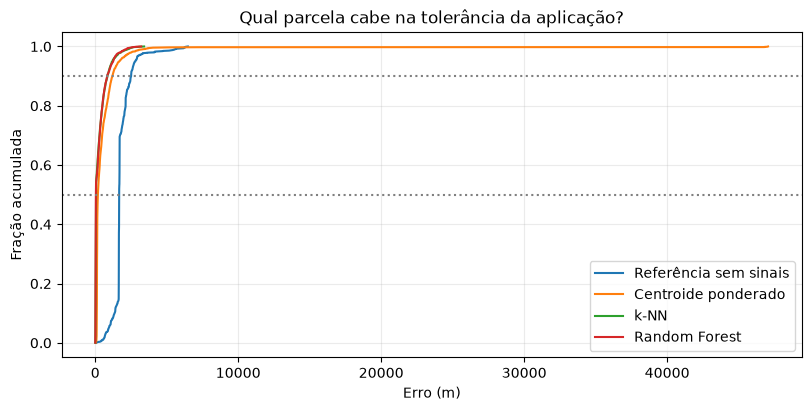

In [10]:
previsoes = estimativas(teste)
resultados_loc, erros = avaliar(teste, previsoes)
display(resultados_loc.round(1))
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for nome, valores in erros.items():
    ax.plot(np.sort(valores), np.arange(1, len(valores)+1)/len(valores), label=nome)
ax.axhline(.5, color='gray', linestyle=':'); ax.axhline(.9, color='gray', linestyle=':')
ax.set(xlabel='Erro (m)', ylabel='Fração acumulada', title='Qual parcela cabe na tolerância da aplicação?')
ax.legend(); plt.show()

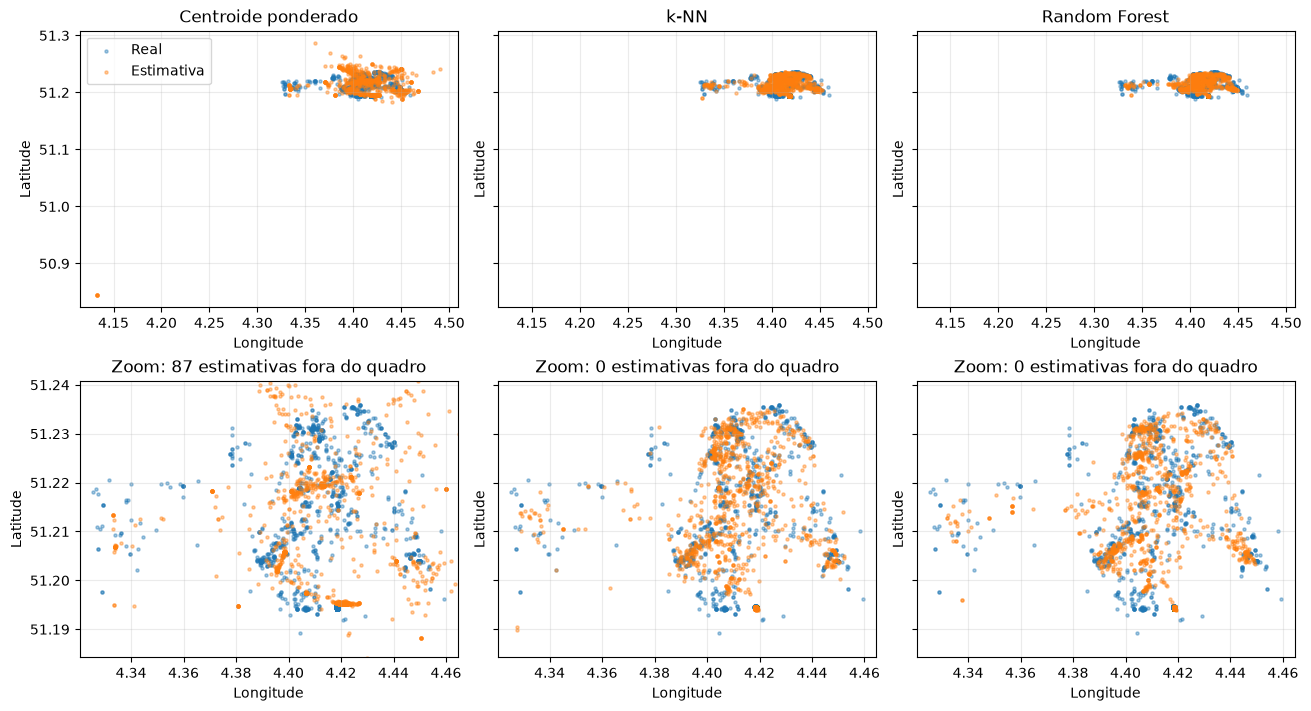

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex='row', sharey='row', constrained_layout=True)
limites_lon = (teste.lon.min() - .005, teste.lon.max() + .005)
limites_lat = (teste.lat.min() - .005, teste.lat.max() + .005)
for coluna, nome in enumerate(['Centroide ponderado', 'k-NN', 'Random Forest']):
    pos = previsoes[nome]
    fora = ((pos[:, 1] < limites_lon[0]) | (pos[:, 1] > limites_lon[1]) |
            (pos[:, 0] < limites_lat[0]) | (pos[:, 0] > limites_lat[1])).sum()
    for linha in range(2):
        ax = axes[linha, coluna]
        ax.scatter(teste.lon, teste.lat, s=5, alpha=.4, label='Real')
        ax.scatter(pos[:, 1], pos[:, 0], s=5, alpha=.4, label='Estimativa')
        ax.set(title=nome if linha == 0 else f'Zoom: {fora} estimativas fora do quadro',
               xlabel='Longitude', ylabel='Latitude')
        if linha == 1:
            ax.set(xlim=limites_lon, ylim=limites_lat)
axes[0, 0].legend(); plt.show()

### Antes de comemorar: o teste cobre situações novas?

**Diagnóstico posterior, sem alterar o split.** Contamos posições em células de 250 × 250 m
na aproximação local e medimos a distância ao GPS de treino mais próximo.
GPS é usado aqui somente para auditar a avaliação, nunca para produzir previsões.
A grade é uma régua descritiva; sua origem e tamanho influenciam as contagens.

Se muitos pacotes de teste voltam a lugares conhecidos, erro baixo significa boa localização
nessas condições — não descobrimento de locais inéditos. Nem Antwerp está livre de concentração.
A última coluna abaixo dá peso igual a cada célula ocupada, resumindo suas medianas de erro.
Não é a mediana por pacote, nem avaliação uniforme de toda a cidade; células pouco amostradas
têm estimativas frágeis. A tabela fica para consulta: em aula, ler a concentração e uma linha.

In [12]:
from sklearn.neighbors import NearestNeighbors
coordenadas_teste = para_metros(teste[['lat', 'lon']])
grade = np.floor(coordenadas_teste / 250).astype(int)
celulas = pd.MultiIndex.from_arrays(grade.T, names=['norte', 'leste'])
ocupacao = pd.Series(1, index=celulas).groupby(level=[0, 1]).sum()
proximidade = NearestNeighbors(n_neighbors=1).fit(y_treino).kneighbors(coordenadas_teste)[0][:, 0]
print(f'Célula mais ocupada: {ocupacao.max()} de {len(teste)} pacotes; {len(ocupacao)} células ocupadas.')
print(f'Posições de teste a até 50 m de alguma posição de treino: {(proximidade <= 50).mean():.1%}')
por_espaco = pd.DataFrame({nome: {
    'Mediana por pacote (m)': np.median(e),
    'Mediana das medianas por célula (m)': pd.Series(e, index=celulas).groupby(level=[0, 1]).median().median(),
} for nome, e in erros.items()}).T
display(por_espaco.round(1))

Célula mais ocupada: 1066 de 2000 pacotes; 205 células ocupadas.
Posições de teste a até 50 m de alguma posição de treino: 92.8%


,Mediana por pacote (m),Mediana das medianas por célula (m)
Referência sem sinais,1671.4,1952.7
Centroide ponderado,183.9,739.0
k-NN,54.7,528.7
Random Forest,44.7,497.5


### O agregado esconde diferenças entre receptores?

Recortamos os erros pelos três gateways destacados **no treino**. Um pacote pode aparecer
em vários grupos. Isso não são modelos treinados por gateway: todos usam o fingerprint completo.
A tabela também separa quantidade de receptores. N e número de dias ajudam a interpretar
a sustentação de cada recorte. Diferenças de erro não provam um efeito causal do gateway.

,Grupo,Método,N,Dias,Mediana (m),P90 (m)
0,080E00B9,Referência sem sinais,1069,4,1666.2,1699.9
1,080E00B9,Centroide ponderado,1069,4,124.7,195.5
2,080E00B9,k-NN,1069,4,31.9,54.2
3,080E00B9,Random Forest,1069,4,27.6,42.5
4,08060716,Referência sem sinais,245,3,1567.5,2437.8
5,08060716,Centroide ponderado,245,3,502.5,1216.5
6,08060716,k-NN,245,3,374.2,1032.5
7,08060716,Random Forest,245,3,345.8,1025.8
8,FF0107C9,Referência sem sinais,295,3,2122.0,2674.4
9,FF0107C9,Centroide ponderado,295,3,653.6,1288.2


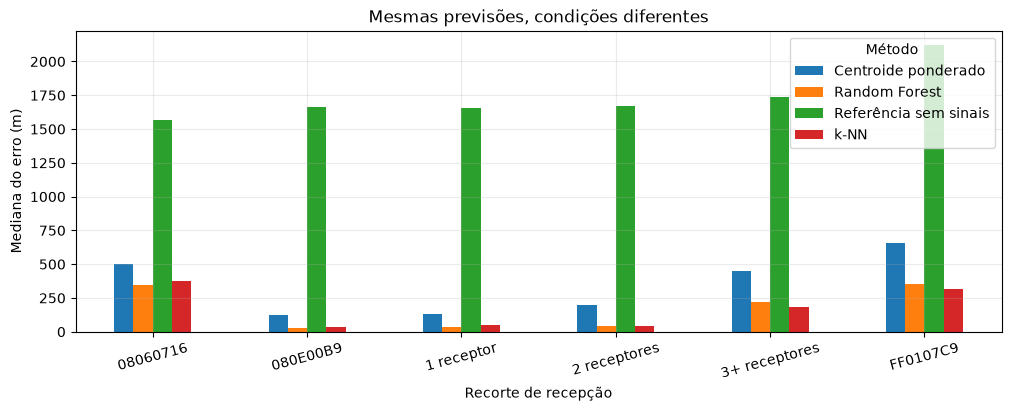

In [13]:
recortes = {coluna.removeprefix('rssi_'): teste[coluna].notna().to_numpy() for coluna in destaques}
quantidade = teste[features].notna().sum(axis=1)
recortes.update({'1 receptor': quantidade.eq(1).to_numpy(),
                '2 receptores': quantidade.eq(2).to_numpy(),
                '3+ receptores': quantidade.ge(3).to_numpy()})
linhas = []
for grupo, mascara in recortes.items():
    if not mascara.any():
        continue
    for nome, valores in erros.items():
        linhas.append({'Grupo': grupo, 'Método': nome, 'N': int(mascara.sum()),
                       'Dias': teste.loc[mascara, 'timestamp'].dt.floor('D').nunique(),
                       'Mediana (m)': np.median(valores[mascara]),
                       'P90 (m)': np.percentile(valores[mascara], 90)})
por_recepcao = pd.DataFrame(linhas)
display(por_recepcao.round(1))
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
por_recepcao.pivot(index='Grupo', columns='Método', values='Mediana (m)').plot.bar(ax=ax, rot=15)
ax.set(ylabel='Mediana do erro (m)', xlabel='Recorte de recepção', title='Mesmas previsões, condições diferentes')
plt.show()

<details><summary>Comentário para discussão</summary>

Uma mediana baixa não garante boa localização para todos os lugares. Recortes por recepção têm composição espacial diferente; não somar as contagens dos gateways nem tratar pacotes próximos como réplicas independentes. Para generalização espacial, seria necessário outro protocolo, definido antes da avaliação.

</details>

## 6 · Contraponto: ML não é bala de prata · 5 min

Em outra campanha LoRa, **Sálvora**, nossa avaliação exploratória encontrou:

| Método | Mediana do erro (m) | P90 (m) |
|---|---:|---:|
| Posição mediana do treino | 201 | 1.407 |
| Centroide ponderado | 246 | 2.003 |
| k-NN | 707 | 1.364 |
| Random Forest | 892 | 1.329 |

Por quê? No teste de Sálvora, 114 dos 226 pacotes estavam a menos de 300 m do gateway 1,
que tinha o RSSI mais forte em 205 pacotes. Um bloco temporal concentrava 103 registros.
Responder sempre a posição do gateway 1 já produzia mediana de 296 m.

O recorte de 300 m foi um diagnóstico posterior, não uma seleção prévia de dados.
Isso ajuda a explicar o resultado, mas não prova uma causa única nem desculpa erros do modelo.
Os números acima são do experimento Sálvora preservado no projeto; não foram calculados em Antwerp.
**Não comparar os erros dos dois datasets como um ranking:** cenários e protocolos são diferentes.

A lição não é “ML sempre vence em Antwerp”. É perguntar **onde os dados estão,
que informação os sinais trazem e qual situação a avaliação representa**.
Antwerp é a prática principal por sua rede multigateway e cobertura urbana, não por um placar esperado.

Complete em voz alta: “Neste teste temporal, o método ____ teve mediana ____ e P90 ____.
Para localizar ____ isso seria ____. Ainda não demonstramos ____.”

### Revisão

- [ ] Diferencio distância entre fingerprints de erro entre posições.
- [ ] Entendo por que RSSI já existe no instante da localização.
- [ ] Sei o que fica no treino, validação e teste.
- [ ] Não confundo análise por gateway com treinamento por gateway.
- [ ] Não interpreto a mediana sem olhar distribuição e cauda.

### Fontes e limites

- Aernouts et al. [Antwerp, Zenodo, v1.3](https://doi.org/10.5281/zenodo.3904158), CC BY 4.0.
- Aernouts et al. [Sigfox and LoRaWAN Datasets for Fingerprint Localization](https://doi.org/10.3390/data3020013), 2018.
- Anagnostopoulos e Kalousis. [A Reproducible Comparison of RSSI Fingerprinting Localization Methods Using LoRaWAN](https://arxiv.org/abs/1908.05085), 2019.
- López Escobar et al. [Sálvora, Zenodo](https://doi.org/10.5281/zenodo.13835721), CC BY 4.0.

O recorte de Antwerp é próprio do tutorial: não reproduz as divisões dos artigos nem sustenta
comparação direta com seus números. Procedência, exclusões, datas e hashes em `data/antwerp_manifest.json`.